<a href="https://drive.google.com/file/d/1AE981iyS_4lKK7Np208Np0bD0L0jKsRm/view?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader

from torchvision.datasets import MNIST
from torchvision.transforms import Compose,ToTensor

from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
import PIL

#### Connect to local google drive & settings for export/import models

In [2]:
drive.mount('/content/gdrive')
!mkdir ./gdrive/'My Drive'/MNIST_models/

Mounted at /content/gdrive


#### DNN model

In [3]:
class DNN(nn.Module):
    def __init__(self,IMG_SIZE=28):
        super(DNN,self).__init__()
        self.fc1 = nn.Linear(IMG_SIZE*IMG_SIZE,32)
        self.BN1 = torch.nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32,10)

    def forward(self,x):
        x = self.fc1(x) # h -> 32
        x = F.relu(x)
        x = self.BN1(x)
        x = self.fc2(x) # 32 -> 10
        x = torch.softmax(x,dim=-1)
        return x

### CNN model

nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True)

- in_channels (int): 입력 채널의 개수. 예를 들어, RGB 이미지의 경우 3개의 채널을 가지므로 in_channels는 3이 됩니다.
- out_channels (int): 출력 채널의 개수, 즉 컨볼루션 필터의 개수입니다. 이 값이 클수록 더 복잡한 특징을 학습할 수 있지만, 모델의 파라미터 수가 증가하게 됩니다.
- kernel_size (int 또는 tuple): 컨볼루션 필터의 크기. 예를 들어, 3x3 필터의 경우 kernel_size는 3 또는 (3, 3)으로 지정할 수 있습니다.
- stride (int 또는 tuple, optional): 필터의 이동 간격, 즉 스트라이드(stride)입니다. 기본값은 1이며, 더 큰 값으로 설정하면 출력 특징 맵의 크기가 작아지게 됩니다.
- padding (int 또는 tuple, optional): 입력 데이터의 가장자리에 추가되는 패딩의 크기입니다. 기본값은 0이며, 패딩을 사용하면 출력 특징 맵의 크기를 보존하면서 입력 데이터의 가장자리 정보를 유지할 수 있습니다.
- dilation (int 또는 tuple, optional): 딜레이션(dilation) 레이트입니다. 딜레이션은 필터의 간격을 더 크게 두어 더 넓은 영역의 정보를 가져오는 데 사용됩니다. 기본값은 1이며, 값이 커질수록 필터의 영역이 더 넓어지게 됩니다.
- groups (int, optional): 입력 및 출력 채널을 묶는(grouping) 개수입니다. 기본값은 1이며, 값이 크면 채널 간의 관련성을 줄이는 효과가 있습니다.
- bias (bool, optional): 편향(bias)을 사용할지 여부를 결정하는 플래그입니다. 기본값은 True이며, False로 설정하면 편향이 사용되지 않습니다.


---
#### Input / Output shape
- **Input**: `(batch_size, 3, 224, 224)` — RGB images normalised with ImageNet stats
- **Output**: `(batch_size, 80)` — raw logits, one per COCO category (no sigmoid needed; the loss handles it)

---
#### How spatial dimensions change through Conv/Pool layers

After each `Conv2d` or `MaxPool2d`, the height/width changes according to:

$$H_{out} = \left\lfloor \frac{H_{in} + 2 \times padding - kernel\_size}{stride} + 1 \right\rfloor$$


If we input 1 * 28 * 28 with a 5 * 5 filter with no padding, and a stride is of 1:

Output = (28 - 5 + 2* (0)) / 1 = 24

In [4]:
import torch
import torch.nn as nn

# 입력 데이터의 크기: (배치 크기, 채널, 높이, 너비)
input_size = (1, 3, 32, 32)

# Conv2d 레이어 정의
conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1)

# 입력 데이터 생성
input_data = torch.randn(input_size)

# 컨볼루션 연산 수행
output = conv(input_data)

# 출력 데이터의 크기 출력
print("Output size:", output.size())

Output size: torch.Size([1, 64, 32, 32])


In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # 첫 번째 레이어: Conv -> ReLU -> MaxPool
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # 두 번째 레이어: Conv -> ReLU -> MaxPool
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # 전결합층 (Fully Connected Layer)
        self.fc = nn.Linear(7 * 7 * 64, 10, bias=True)
        # 가중치 초기화
        nn.init.xavier_uniform_(self.fc.weight)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1) # Flatten
        out = self.fc(out)
        return out

### Util function for calculating accuracy

In [6]:
def compute_acc(argmax,y):
    count = 0
    for i in range(len(argmax)):
        if argmax[i]==y[i]:
            count+=1
    return count / len(argmax)

### Define Hyperparameters

In [7]:
IMG_SIZE = 28
BATCH_SIZE = 256
LEARNING_RATE = 0.001
NUM_EPOCHES = 10

### Load Dataset

In [8]:
transforms = Compose([
    ToTensor(),
])

trainset = MNIST('/content/gdrive/My Drive/MNIST_models/',train=True,transform=transforms,download=True)
testset = MNIST('/content/gdrive/My Drive/MNIST_models/',train=False,transform=transforms,download=True)

args = {
    'num_workers' : 1,
    'batch_size' : BATCH_SIZE,
    'shuffle' : True,
}

train_loader = DataLoader(trainset,**args)
test_loader = DataLoader(testset,**args)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 540kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.9MB/s]


torch.Size([256, 1, 28, 28]) torch.Size([256])


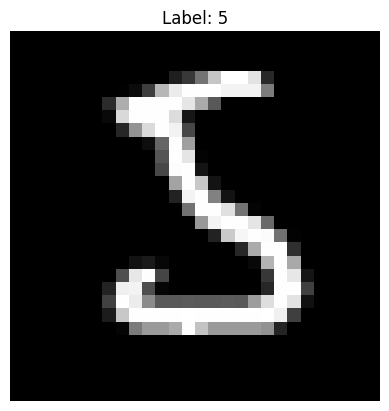

In [38]:
import matplotlib.pyplot as plt

for images, labels in train_loader:
    print(images.shape , labels.shape)
    cur_img, cur_label = images[0], labels[0]
    plt.imshow(cur_img.squeeze(), cmap='gray')
    plt.title(f"Label: {cur_label.item()}")
    plt.axis('off')
    plt.show()

    break

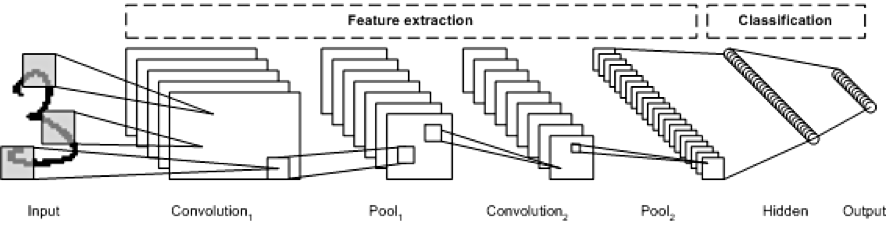

## Define functions

In [44]:
def train_MNIST(model,
                optimizer,
                loss_fn,
                train_loader,
                num_epochs,
                IMG_SIZE=28,
                model_save_path="/content/gdrive/My Drive/MNIST_models/model.pt"
                ):
    avg_loss_list = []

    for epoch in range(num_epochs):
        tot_loss = 0.0

        for images, labels in train_loader:
            optimizer.zero_grad()
            images, labels = images.cuda(), labels.cuda()

            if isinstance(model, DNN):
                images = images.view(-1,IMG_SIZE*IMG_SIZE)

            predictions = model(images)
            loss = loss_fn(predictions, labels)
            loss.backward()
            optimizer.step()

            tot_loss += loss.item()

        avg_loss = tot_loss / len(train_loader)
        avg_loss_list.append(avg_loss)

        print("Epoch {}, Loss(train) : {:.5}".format(epoch+1, avg_loss))

    if model_save_path:
        torch.save(model.state_dict(), model_save_path)
        print(f"Save the model at {model_save_path}")

    return avg_loss_list

In [45]:
def test_MNIST(model, test_loader, IMG_SIZE=28):
    model.eval()

    total = 0
    correct = 0
    tot_loss = 0.0

    loss_fn = nn.CrossEntropyLoss(reduction='sum')

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.cuda(), labels.cuda()

            if isinstance(model, DNN):
                images = images.view(-1,IMG_SIZE*IMG_SIZE)

            predictions = model(images)

            loss = loss_fn(predictions, labels)
            tot_loss += loss.item()

            _, pred = torch.max(predictions, dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

    avg_loss = tot_loss / total
    acc = correct / total

    print(f"Test Loss: {avg_loss:.5f}, Accuracy: {acc:.5f}")

    return avg_loss, acc

In [46]:
import matplotlib.pyplot as plt

def plot_losses(loss_list):
    epochs = range(1, len(loss_list) + 1)

    plt.figure()
    plt.plot(epochs, loss_list, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss over Epochs')
    plt.grid(True)
    plt.show()

Train DNN Model

In [47]:
model = DNN(IMG_SIZE).cuda()
optimizer = Adam(model.parameters(),lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()

DNN_loss = train_MNIST(model, optimizer, loss_fn, train_loader, num_epochs=NUM_EPOCHES, model_save_path="/content/gdrive/My Drive/MNIST_models/DNN.pt")

Epoch 1, Loss(train) : 1.7292
Epoch 2, Loss(train) : 1.5683
Epoch 3, Loss(train) : 1.5401
Epoch 4, Loss(train) : 1.526
Epoch 5, Loss(train) : 1.5159
Epoch 6, Loss(train) : 1.5093
Epoch 7, Loss(train) : 1.5037
Epoch 8, Loss(train) : 1.4996
Epoch 9, Loss(train) : 1.4959
Epoch 10, Loss(train) : 1.4937
Save the model at /content/gdrive/My Drive/MNIST_models/DNN.pt


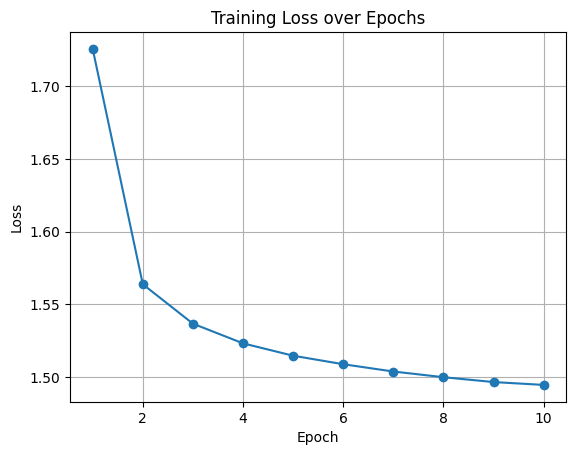

In [14]:
plot_losses(DNN_loss)

Test DNN Model

In [49]:
model_test = DNN(IMG_SIZE).cuda()
model_test.load_state_dict(torch.load("/content/gdrive/My Drive/MNIST_models/DNN.pt"))
test_loss, acc = test_MNIST(model, test_loader)

Test Loss: 1.50481, Accuracy: 0.96160


#### Training part(CNN)

In [50]:
model = CNN().cuda()
optimizer = Adam(model.parameters(),lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()

CNN_loss = train_MNIST(model, optimizer, loss_fn, train_loader, 10, model_save_path="/content/gdrive/My Drive/MNIST_models/CNN.pt")

Epoch 1, Loss(train) : 0.38167
Epoch 2, Loss(train) : 0.089958
Epoch 3, Loss(train) : 0.063852
Epoch 4, Loss(train) : 0.052102
Epoch 5, Loss(train) : 0.043673
Epoch 6, Loss(train) : 0.038936
Epoch 7, Loss(train) : 0.033596
Epoch 8, Loss(train) : 0.029376
Epoch 9, Loss(train) : 0.026456
Epoch 10, Loss(train) : 0.023896
Save the model at /content/gdrive/My Drive/MNIST_models/CNN.pt


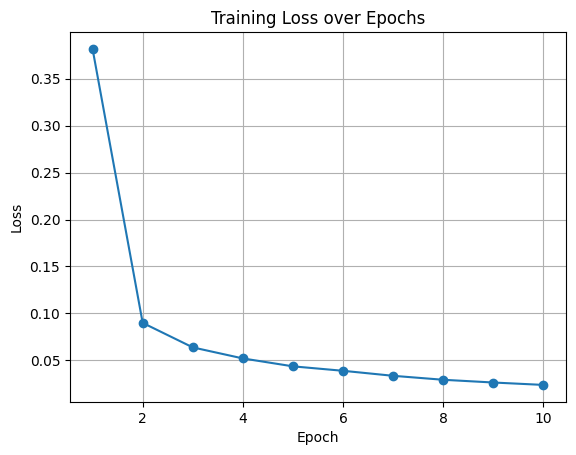

In [51]:
plot_losses(CNN_loss)

In [52]:
model_test = CNN().cuda()
model_test.load_state_dict(torch.load("/content/gdrive/My Drive/MNIST_models/CNN.pt"))
test_loss, acc = test_MNIST(model, test_loader)

Test Loss: 0.03630, Accuracy: 0.98770


---
## Practice: Vision Model on MSCOCO Classification

In this practice section, you will:
1. Load the **MSCOCO 2017** dataset
2. **Implement your own vision model** (CNN or any architecture you like)
3. Train and evaluate it on an **80-class multi-label classification** task

> **What is multi-label classification?**  
> A single COCO image can contain multiple objects (e.g., a person *and* a dog).  
> Unlike MNIST where each image has exactly one label, here the model must predict  
> *which subset* of the 80 COCO categories are present in the image.

**Loss function**: `BCEWithLogitsLoss` (binary cross-entropy per class)  
**Metric**: per-class accuracy averaged over all 80 classes (mean accuracy @ threshold 0.5)

In [55]:
# Install pycocotools (COCO API)
!pip install pycocotools -q

In [54]:
import os
import json
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import numpy as np

### Download MSCOCO 2017 Dataset

Run the cell below to download COCO 2017 images and annotations into Google Drive.  
This may take a while (~18 GB for train, ~1 GB for val).  
If you already have COCO downloaded, update `COCO_ROOT` to point to the existing directory.

In [56]:
# ── Paths ──────────────────────────────────────────────────────────────────
COCO_ROOT = "/content/gdrive/MyDrive/COCO2017"
TRAIN_IMG_DIR  = os.path.join(COCO_ROOT, "train2017")
VAL_IMG_DIR    = os.path.join(COCO_ROOT, "val2017")
TRAIN_ANN_FILE = os.path.join(COCO_ROOT, "annotations", "instances_train2017.json")
VAL_ANN_FILE   = os.path.join(COCO_ROOT, "annotations", "instances_val2017.json")

os.makedirs(COCO_ROOT, exist_ok=True)
os.makedirs(os.path.join(COCO_ROOT, "annotations"), exist_ok=True)

# Download annotations (~241 MB)
if not os.path.exists(TRAIN_ANN_FILE):
    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P "{COCO_ROOT}"
    !unzip -q "{COCO_ROOT}/annotations_trainval2017.zip" -d "{COCO_ROOT}"

# Download validation images (~1 GB) — use this for quick experiments
if not os.path.exists(VAL_IMG_DIR):
    !wget -q http://images.cocodataset.org/zips/val2017.zip -P "{COCO_ROOT}"
    !unzip -q "{COCO_ROOT}/val2017.zip" -d "{COCO_ROOT}"

# (Optional) Download train images (~18 GB) — comment out if using val only
# if not os.path.exists(TRAIN_IMG_DIR):
#     !wget -q http://images.cocodataset.org/zips/train2017.zip -P "{COCO_ROOT}"
#     !unzip -q "{COCO_ROOT}/train2017.zip" -d "{COCO_ROOT}"

print("Dataset ready!")

Dataset ready!


### COCO Multi-Label Classification Dataset

In [57]:
class COCOClassificationDataset(Dataset):
    """
    Wraps COCO 2017 as a multi-label classification dataset.
    Each sample is (image_tensor, label_vector) where label_vector
    is a float tensor of shape (80,) with 1.0 for each category present.
    """
    def __init__(self, img_dir, ann_file, transform=None):
        self.coco      = COCO(ann_file)
        self.img_dir   = img_dir
        self.transform = transform

        # Keep only images that have at least one annotation
        all_ids = list(sorted(self.coco.imgs.keys()))
        self.ids = [img_id for img_id in all_ids
                    if len(self.coco.getAnnIds(imgIds=img_id)) > 0]

        # Map COCO category ids (not contiguous) -> [0, 79]
        self.cat_ids    = sorted(self.coco.getCatIds())
        self.cat_to_idx = {cat_id: idx for idx, cat_id in enumerate(self.cat_ids)}
        self.num_classes = len(self.cat_ids)  # 80

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        img_id   = self.ids[index]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)

        # Build multi-hot label vector
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns    = self.coco.loadAnns(ann_ids)
        label   = torch.zeros(self.num_classes, dtype=torch.float32)
        for ann in anns:
            idx = self.cat_to_idx[ann['category_id']]
            label[idx] = 1.0

        return img, label

    def get_category_names(self):
        """Returns the list of 80 category names in index order."""
        cats = self.coco.loadCats(self.cat_ids)
        return [c['name'] for c in cats]

loading annotations into memory...
Done (t=0.56s)
creating index...
index created!
Validation images (with annotations): 4952
Number of classes: 80


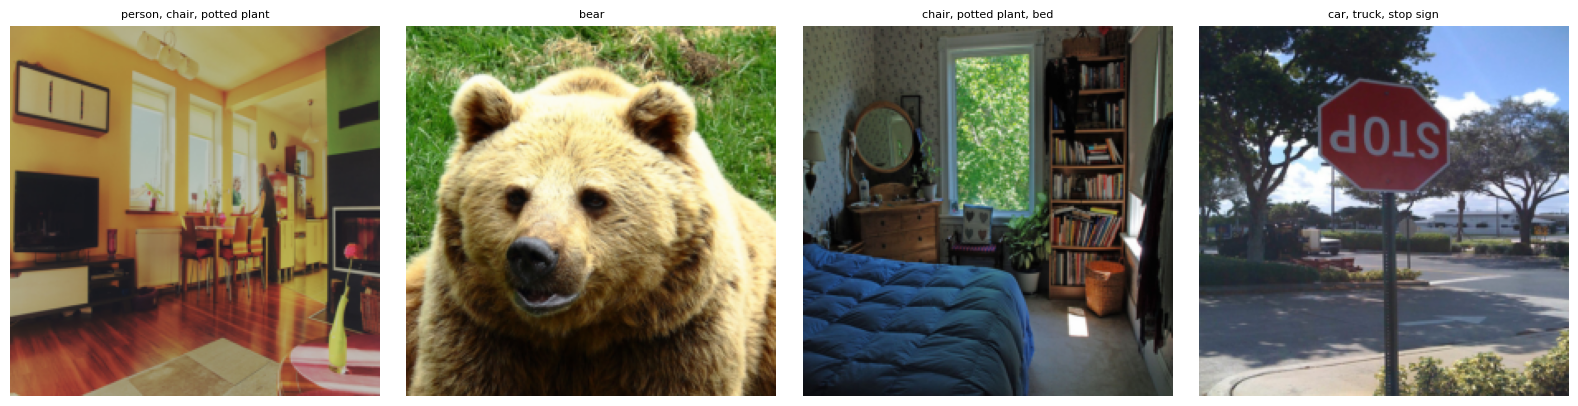

In [58]:
# Quick sanity-check: visualise a few images and their labels
preview_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

preview_dataset = COCOClassificationDataset(VAL_IMG_DIR, VAL_ANN_FILE, transform=preview_transform)
category_names  = preview_dataset.get_category_names()
print(f"Validation images (with annotations): {len(preview_dataset)}")
print(f"Number of classes: {preview_dataset.num_classes}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, idx in zip(axes, range(4)):
    img_tensor, label = preview_dataset[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()
    present = [category_names[i] for i in range(len(label)) if label[i] == 1.0]
    ax.imshow(img_np)
    ax.set_title(", ".join(present[:3]), fontsize=8)  # show up to 3 labels
    ax.axis('off')
plt.tight_layout()
plt.show()

### Hyperparameters

In [59]:
COCO_IMG_SIZE    = 224     # resize all images to 224x224
COCO_BATCH_SIZE  = 64
COCO_LR          = 0.001
COCO_NUM_EPOCHS  = 10
NUM_CLASSES      = 80
THRESHOLD        = 0.5     # sigmoid threshold for predicting a class as present

In [60]:
coco_train_transform = transforms.Compose([
    transforms.Resize((COCO_IMG_SIZE, COCO_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),  # ImageNet stats
])

coco_val_transform = transforms.Compose([
    transforms.Resize((COCO_IMG_SIZE, COCO_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# NOTE: swap VAL_IMG_DIR / VAL_ANN_FILE for TRAIN_IMG_DIR / TRAIN_ANN_FILE
# once you have the full training set downloaded.
coco_train_dataset = COCOClassificationDataset(VAL_IMG_DIR, VAL_ANN_FILE,
                                               transform=coco_train_transform)
coco_val_dataset   = COCOClassificationDataset(VAL_IMG_DIR, VAL_ANN_FILE,
                                               transform=coco_val_transform)

coco_train_loader = DataLoader(coco_train_dataset, batch_size=COCO_BATCH_SIZE,
                               shuffle=True,  num_workers=2, pin_memory=True)
coco_val_loader   = DataLoader(coco_val_dataset,   batch_size=COCO_BATCH_SIZE,
                               shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(coco_train_loader)}")
print(f"Val   batches : {len(coco_val_loader)}")

loading annotations into memory...
Done (t=0.71s)
creating index...
index created!
loading annotations into memory...
Done (t=0.54s)
creating index...
index created!
Train batches : 78
Val   batches : 78


### Your Model

Implement your vision model in the class below.

For example, starting from **224×224**:

| Layer | kernel | stride | padding | Output H×W |
|-------|--------|--------|---------|------------|
| Conv2d | 3 | 1 | 1 | 224×224 |
| MaxPool2d | 2 | 2 | 0 | 112×112 |
| Conv2d | 3 | 1 | 1 | 112×112 |
| MaxPool2d | 2 | 2 | 0 | 56×56 |
| Conv2d | 3 | 1 | 1 | 56×56 |
| MaxPool2d | 2 | 2 | 0 | 28×28 |

So if the last conv outputs **64 channels** at **28×28**, the flattened size fed to `nn.Linear` is `64 × 28 × 28 = 50176`.


```
image_tensor = torch.tensor([
    [1, 1, 1, 1],
    [2, 2, 2, 2],
    [3, 3, 3, 3],
    [4, 4, 4, 4],
])

max_pooling_layer = nn.MaxPool2d(2, 2) # size, stride

max_pooling_layer(image_tensor.view(1, 1, 4, 4))
-> tensor([[[[2, 2],[4, 4]]]])

```

> **Tip — avoid manual calculation with `AdaptiveAvgPool2d`**  
> `nn.AdaptiveAvgPool2d((1, 1))` collapses any spatial size to **1×1**, so the flattened
> dimension is always just `num_channels`. This lets you change conv depth freely without
> recomputing the linear input size.

---
#### Debugging dimensions with a dry run

If you are unsure of the shape at any point, run a **dummy forward pass** before training:

```python
model = MyVisionModel().cuda()
dummy = torch.zeros(1, 3, 224, 224).cuda()   # single fake image
out   = model(dummy)
print(out.shape)   # should be torch.Size([1, 80])
```

You can also print intermediate shapes inside `forward` while debugging:

```python
def forward(self, x):
    x = self.layer1(x);  print(x.shape)   # e.g. torch.Size([1, 32, 112, 112])
    x = self.layer2(x);  print(x.shape)
    ...
```

Remove the `print` calls once the shapes look correct.





In [64]:
class MyVisionModel(nn.Module):
    def __init__(self, num_classes=80):
        super(MyVisionModel, self).__init__()

        # ------------------------------------------------------------------ #
        # TODO: Define your layers here.                                       #
        #                                                                      #
        # Option A — manual flatten (you must compute the linear input size):  #
        #                                                                      #
        self.features = nn.Sequential(                                     #
              nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),          #
              nn.BatchNorm2d(32),                                            #
              nn.ReLU(),                                                     #
              nn.MaxPool2d(2, 2),   # 224 -> 112                             #
              nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),         #
              nn.BatchNorm2d(64),                                            #
              nn.ReLU(),                                                     #
              nn.MaxPool2d(2, 2),   # 112 -> 56                              #
              nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),         #
              nn.BatchNorm2d(64),                                            #
              nn.ReLU(),                                                     #
              nn.MaxPool2d(2, 2),   # 56 -> 28
          )                                                                  #
        # After 2 MaxPool(2,2): 224 -> 56; channels = 64                   #
        # Flattened size = 64 * 56 * 56 = 200704                           #
        self.classifier = nn.Linear(64 * 56 * 56, num_classes)             #

    def forward(self, x):
        # ------------------------------------------------------------------   #
        # TODO: Define the forward pass.                                       #
        #                                                                      #
        # Option A (manual flatten):                                           #
        x = self.features(x)                                               #
        x = x.view(x.size(0), -1)   # flatten: (B, C, H, W) -> (B, C*H*W). #
        x = self.classifier(x)                                             #
        return x                                                           #


# ── Dimension sanity check ─────────────────────────────────────────────────
# Uncomment and run after implementing the model to verify output shape:

model = MyVisionModel().cuda()
dummy = torch.zeros(1, 3, 224, 224).cuda()
print(model(dummy).shape)   # expected: torch.Size([1, 80])

torch.Size([1, 80])


# Implement your own vision model

In [69]:
class MyVisionModel(nn.Module):
    def __init__(self, num_classes=80):
        super(MyVisionModel, self).__init__()

        # ------------------------------------------------------------------ #
        # TODO: Define your layers here.                                       #
        #                                                                      #
        # Option A — manual flatten (you must compute the linear input size):  #
        #                                                                      #
        #   self.features = nn.Sequential(                                     #
        #       nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),          #
        #       nn.BatchNorm2d(32),                                            #
        #       nn.ReLU(),                                                     #
        #       nn.MaxPool2d(2, 2),   # 224 -> 112                             #
        #       nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),         #
        #       nn.BatchNorm2d(64),                                            #
        #       nn.ReLU(),                                                     #
        #       nn.MaxPool2d(2, 2),   # 112 -> 56                              #
        #   )                                                                  #
        #   # After 2 MaxPool(2,2): 224 -> 56; channels = 64                   #
        #   # Flattened size = 64 * 56 * 56 = 200704                           #
        #   self.classifier = nn.Linear(64 * 56 * 56, num_classes)             #
        #                                                                      #
        # Option B — AdaptiveAvgPool (recommended, no manual calculation):     #
        #                                                                      #
        self.features = nn.Sequential(                                     #
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),          #
            nn.BatchNorm2d(32),                                            #
            nn.ReLU(),                                                     #
            nn.MaxPool2d(2, 2),                                            #
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),         #
            nn.BatchNorm2d(64),                                            #
            nn.ReLU(),                                                     #
            nn.MaxPool2d(2, 2),                                            #
        )                                                                  #
        self.pool = nn.AdaptiveAvgPool2d((1, 1))  # any H,W -> 1x1         #
        # Flattened size is always just num_channels (64 here)             #
        self.classifier = nn.Linear(64, num_classes)                       #
        # ------------------------------------------------------------------   #
        pass

    def forward(self, x):
        # ------------------------------------------------------------------   #
        # TODO: Define the forward pass.                                       #
        #                                                                      #
        # Option A (manual flatten):                                           #
        #   x = self.features(x)                                               #
        #   x = x.view(x.size(0), -1)   # flatten: (B, C, H, W) -> (B, C*H*W). #
        #   x = self.classifier(x)                                             #
        #   return x                                                           #
        #                                                                      #
        # Option B (AdaptiveAvgPool):                                          #
        x = self.features(x)                                               #
        x = self.pool(x)            # (B, C, H, W) -> (B, C, 1, 1)         #
        x = x.view(x.size(0), -1)   # (B, C, 1, 1) -> (B, C)               #
        x = self.classifier(x)                                             #
        return x                                                           #
        # ------------------------------------------------------------------   #
        # pass


# ── Dimension sanity check ─────────────────────────────────────────────────
# Uncomment and run after implementing the model to verify output shape:
#
model = MyVisionModel().cuda()
dummy = torch.zeros(1, 3, 224, 224).cuda()
print(model(dummy).shape)   # expected: torch.Size([1, 80])

torch.Size([1, 80])


### Training & Evaluation Functions

In [65]:
from tqdm import tqdm

def train_COCO(model, optimizer, loss_fn, train_loader, num_epochs,
               model_save_path="/content/gdrive/My Drive/COCO2017/my_vision_model.pt"):
    model.train()
    avg_loss_list = []

    for epoch in range(num_epochs):
        tot_loss = 0.0

        for images, labels in tqdm(train_loader, total=len(train_loader)):
            images, labels = images.cuda(), labels.cuda()

            optimizer.zero_grad()
            logits = model(images)          # (B, 80)
            loss   = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()

            tot_loss += loss.item()

        avg_loss = tot_loss / len(train_loader)
        avg_loss_list.append(avg_loss)
        print(f"Epoch {epoch+1}/{num_epochs}  Loss: {avg_loss:.5f}")

    if model_save_path:
        torch.save(model.state_dict(), model_save_path)
        print(f"Model saved to {model_save_path}")

    return avg_loss_list

In [66]:
from tqdm import tqdm

def test_COCO(model, val_loader, threshold=0.5):
    """
    Evaluates multi-label classification performance.
    Reports:
      - Mean per-class accuracy (fraction of images where the prediction
        for each class matches the ground truth, averaged over 80 classes)
      - Overall exact-match accuracy (all 80 bits correct for an image)
    """
    model.eval()
    loss_fn = nn.BCEWithLogitsLoss(reduction='sum')

    tot_loss       = 0.0
    total_images   = 0
    # per-class correct counts
    class_correct  = torch.zeros(NUM_CLASSES)
    exact_match    = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, total=len(val_loader)):
            images, labels = images.cuda(), labels.cuda()

            logits = model(images)
            tot_loss += loss_fn(logits, labels).item()

            preds = (torch.sigmoid(logits) >= threshold).float()  # (B, 80)

            class_correct += (preds == labels).float().sum(dim=0).cpu()
            exact_match   += (preds == labels).all(dim=1).sum().item()
            total_images  += images.size(0)

    per_class_acc = class_correct / total_images          # (80,)
    mean_acc      = per_class_acc.mean().item()
    exact_acc     = exact_match / total_images
    avg_loss      = tot_loss / (total_images * NUM_CLASSES)

    print(f"Val Loss          : {avg_loss:.5f}")
    print(f"Mean Class Acc    : {mean_acc:.4f}  ({mean_acc*100:.2f}%)")
    print(f"Exact-Match Acc   : {exact_acc:.4f}  ({exact_acc*100:.2f}%)")

    return avg_loss, mean_acc, exact_acc, per_class_acc

### Train Your Model

In [70]:
my_model  = MyVisionModel(num_classes=NUM_CLASSES).cuda()
optimizer = Adam(my_model.parameters(), lr=COCO_LR)
loss_fn   = nn.BCEWithLogitsLoss()

coco_loss = train_COCO(my_model, optimizer, loss_fn, coco_train_loader,
                       num_epochs=COCO_NUM_EPOCHS, model_save_path="/content/gdrive/My Drive/COCO2017/my_vision_model.pt")

100%|██████████| 78/78 [01:04<00:00,  1.22it/s]


Epoch 1/10  Loss: 0.30470


100%|██████████| 78/78 [00:59<00:00,  1.30it/s]


Epoch 2/10  Loss: 0.14406


100%|██████████| 78/78 [01:01<00:00,  1.28it/s]


...

Epoch 8/10  Loss: 0.12977


100%|██████████| 78/78 [00:59<00:00,  1.31it/s]


Epoch 9/10  Loss: 0.12894


100%|██████████| 78/78 [00:59<00:00,  1.31it/s]

Epoch 10/10  Loss: 0.12821
Model saved to /content/gdrive/My Drive/COCO2017/my_vision_model.pt


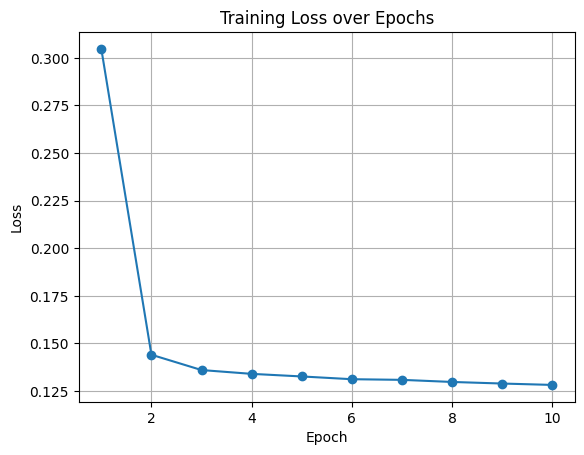

In [71]:
plot_losses(coco_loss)

### Evaluate Your Model

In [72]:
val_loss, mean_acc, exact_acc, per_class_acc = test_COCO(my_model, coco_val_loader)

# Show per-class accuracy for the 10 easiest and 10 hardest classes
sorted_idx = per_class_acc.argsort(descending=True)
print("\nTop-10 easiest classes:")
for i in sorted_idx[:10]:
    print(f"  {category_names[i]:20s}  {per_class_acc[i]:.4f}")

print("\nTop-10 hardest classes:")
for i in sorted_idx[-10:]:
    print(f"  {category_names[i]:20s}  {per_class_acc[i]:.4f}")

100%|██████████| 78/78 [00:49<00:00,  1.57it/s]

Val Loss          : 0.12795
Mean Class Acc    : 0.9650  (96.50%)
Exact-Match Acc   : 0.0026  (0.26%)

Top-10 easiest classes:
  toaster               0.9984
  hair drier            0.9982
  scissors              0.9943
  toothbrush            0.9931
  parking meter         0.9925
  snowboard             0.9901
  bear                  0.9901
  hot dog               0.9897
  microwave             0.9891
  donut                 0.9875

Top-10 hardest classes:
  bench                 0.9525
  truck                 0.9495
  handbag               0.9410
  bowl                  0.9366
  bottle                0.9235
  cup                   0.9212
  dining table          0.8978
  car                   0.8920
  chair                 0.8829
  person                0.6115
